In [1]:
from pathlib import Path
import pandas as pd
import argparse
from pathlib import Path
from typing import List, Tuple, Optional, Callable
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16

In [8]:
def choi_to_superop(J: np.ndarray) -> np.ndarray:
    '''Convert a Choi matrix J (d^2 x d^2) to superoperator S under Qiskit convention J=(I⊗E)(|Φ><Φ|).'''
    d2 = J.shape[0]
    d = int(np.sqrt(d2))
    # reshape to J4[i,j,k,l] = J_{(i,j),(k,l)}
    J4 = J.reshape((d, d, d, d))
    # under (I⊗E) convention, S_{(i,j),(k,l)} = J_{(k,i),(l,j)}
    # transpose indices: (i,j,k,l) -> (k,i,l,j)
    S4 = J4.transpose(2, 0, 3, 1)
    # flatten to (d^2, d^2)
    return S4.reshape(d2, d2)


def superop_to_choi(S: np.ndarray) -> np.ndarray:
    '''Convert a superoperator S (d^2 x d^2) back to Choi J under Qiskit convention.'''
    d2 = S.shape[0]
    d = int(np.sqrt(d2))
    # reshape to S4[j,l,i,k]
    S4 = S.reshape((d, d, d, d))
    # inverse transpose: (j,l,i,k) -> (i,j,k,l)
    J4 = S4.transpose(1, 3, 0, 2)
    # flatten back to (d^2, d^2)
    return J4.reshape(d2, d2)


def compute_min_eigenvalues(time_us: np.ndarray,
                            choi_stack: np.ndarray,
                            s_index: int) -> Tuple[np.ndarray, np.ndarray]:
    '''Compute the minimum eigenvalue of the intermediate Choi map from s_index to each t>=s_index.

    Args:
        time_us: array of times (length N)
        choi_stack: array of shape (N, d2, d2) of Choi matrices
        s_index: index in [0, N) for the starting time point

    Returns:
        times_out: times at indices >= s_index
        min_eigs: array of minimum eigenvalues of chi_{s,t}
    '''
    N, d2, _ = choi_stack.shape
    # superoperator at s
    S_s = choi_to_superop(choi_stack[s_index])
    # pseudo-inverse if necessary
    S_s_inv = np.linalg.pinv(S_s)
    print(np.linalg.eigvals(choi_stack[s_index]))
    print(np.linalg.eigvals(superop_to_choi(S_s_inv)))
    times_out = time_us[s_index:]
    min_eigs = np.zeros_like(times_out)
    for idx, t in enumerate(range(s_index, N)):
        S_t = choi_to_superop(choi_stack[t])
        S_st = S_t @ S_s_inv
        J_st = superop_to_choi(S_st)
        # compute Hermitian eigenvalues
        eigs = np.linalg.eigvals(0.5*(J_st + J_st.conj().T))
        min_eigs[idx] = np.min(eigs)
    return times_out, min_eigs


def plot_divisibility(file_paths, s_index=None):
    '''Load .npz files, compute min eigenvalues, and plot versus time for each file.'''
    plt.figure()
    for path in file_paths:
        data = np.load(path)
        time_us = data['time_us']
        choi = data['choi']  # shape (N, d2, d2)
        times, min_eigs = compute_min_eigenvalues(time_us, choi, s_index)
        label = Path(path).stem
        plt.plot(times, min_eigs, marker='o', label=label)
    plt.axhline(0, linestyle='--')
    plt.xlabel('Idle time (µs)')
    plt.ylabel('Min eigenvalue of $\\chi_{s,t}$')
    plt.title(f'CP-divisibility test (s_index={s_index})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def _min_eig_chi_st(S_t: np.ndarray, S_s_inv: np.ndarray) -> float:
    """Return min‑eig of χ_{s,t} = ℰ_{s,t}’s Choi matrix."""
    J_st = superop_to_choi(S_t @ S_s_inv)
    # Hermitian‑symmetrise to kill tiny non‑Hermiticity
    J_st = 0.5 * (J_st + J_st.conj().T)
    return np.min(np.linalg.eigvalsh(J_st).real)

def build_min_eig_matrix(choi_stack: np.ndarray) -> np.ndarray:
    """
    Return an N×N matrix M with
        M[s, t] = min‑eig(χ_{s,t})   for s ≤ t
                =  nan               for s > t   (masked region)
    """
    N, d2, _ = choi_stack.shape
    # pre‑compute super‑operators S(t)
    S_stack = np.array([choi_to_superop(J) for J in choi_stack])
    M = np.full((N, N), np.nan)

    for s in range(N):
        S_s_inv = np.linalg.pinv(S_stack[s])
        for t in range(s, N):
            M[s, t] = _min_eig_chi_st(S_stack[t], S_s_inv)
    return M

def plot_divisibility_heatmap(file_paths, vmin=None, vmax=None):
    """
    For every .npz file supplied, draw a triangular heat‑map of
    min‑eig(χ_{s,t}) (s ≤ t).  One figure per file.
    """
    for path in file_paths:
        data      = np.load(path)
        time_us   = data['time_us']              # shape (N,)
        choi_stack = data['choi']                # shape (N, d2, d2)

        M = build_min_eig_matrix(choi_stack)     # N×N triangular matrix
        mask = np.isnan(M)

        fig, ax = plt.subplots(figsize=(6, 5))
        if vmin == None:
            vmin = np.min(np.ma.masked_array(M, mask))
            print(f"vmin = {vmin}")
        if vmax == None: 
            vmax = np.max(np.ma.masked_array(M, mask))
            print(f"vmax = {vmax}")
        cax = ax.imshow(
            np.ma.masked_array(M, mask),         # mask s>t
            origin='lower',
            cmap='magma',
            vmin=vmin,
            vmax=vmax,
            extent=[time_us[0], time_us[-1], time_us[0], time_us[-1]],
            aspect='auto'
        )
        ax.set_xlabel(r'$t$  (idle time $\mu s$)')
        ax.set_ylabel(r'$s$  (start time $\mu s$)')
        # ax.set_title(f'CP‑divisibility:  min eig $\\chi_{{s,t}}$  —  {Path(path).stem}')
        fig.colorbar(cax, label=r'$\lambda_{\min}(\chi_{s,t})$')
        ax.grid(False)
        plt.tight_layout()
        plt.savefig(f"images/cp_divisibility_heatmap_{Path(path).stem}.pdf", dpi=300, bbox_inches='tight')

In [9]:
file_paths = [
    # "results/process_tomography/crosstalk/ibm_strasbourg/init+/q[25, 26, 27, 16]-np50-gpp50-s8192-2025-05-11T11-58-40.npz",
    "results/process_tomography/crosstalk/ibm_strasbourg/init+/q[4, 3, 5, 15]-np50-gpp50-s8192-2025-05-10T11-34-55.npz",
]

vmin = -23.149732266824458


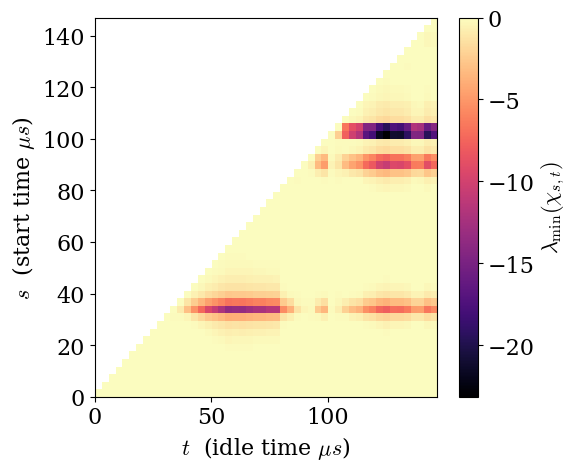

In [10]:
plot_divisibility_heatmap(file_paths, vmax=0.0)

vmin = -33.00288753523909


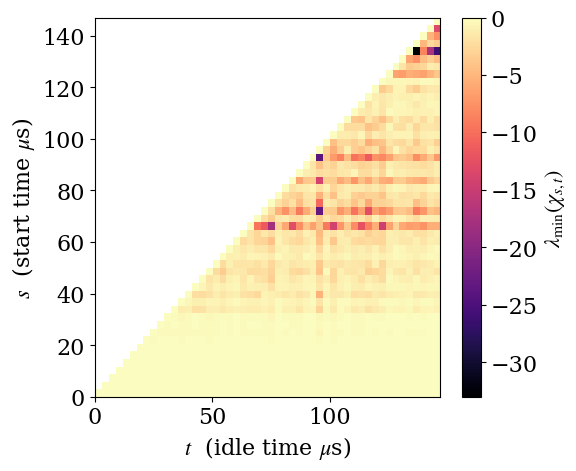

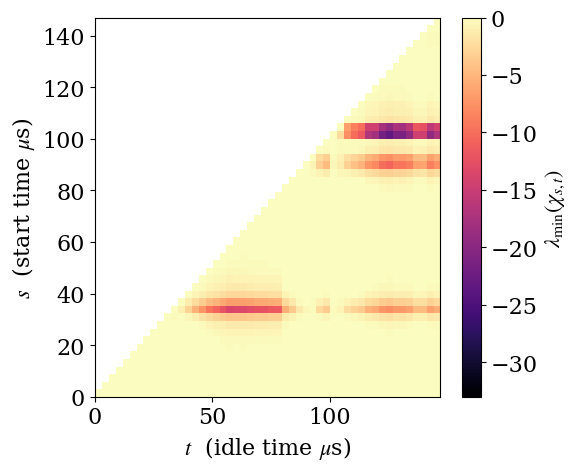

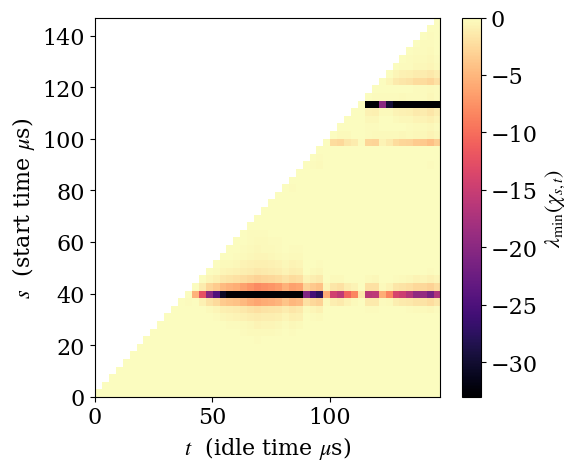

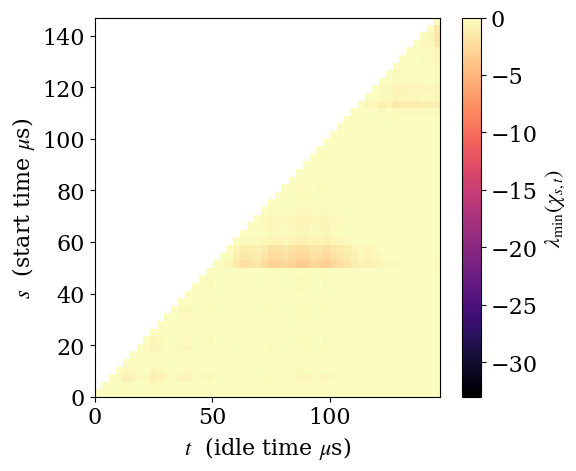

In [4]:
plot_divisibility_heatmap(file_paths, vmax=0.0)